# 📙 Unsupervised Learning — Complete Revision Notes

Covers **Clustering**, **Dimensionality Reduction**, **Anomaly Detection**, and
**Association Rule Learning** — every major unsupervised technique with theory + code.

**Datasets used:** `iris` (seaborn) for most sections, plus `make_blobs`/`make_moons` (synthetic)
to clearly visualize how different clustering algorithms behave on different shapes.


In [1]:
# If any of these are missing, uncomment and run:
# !pip install umap-learn mlxtend scikit-learn seaborn pandas numpy scipy --quiet


## 1. Imports

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs, make_moons
from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from scipy.cluster.hierarchy import dendrogram, linkage

from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor

import warnings
warnings.filterwarnings("ignore")

try:
    import umap
    UMAP_AVAILABLE = True
except ImportError:
    UMAP_AVAILABLE = False
    print("umap-learn not installed -> pip install umap-learn")

try:
    from mlxtend.frequent_patterns import apriori, association_rules
    from mlxtend.preprocessing import TransactionEncoder
    MLXTEND_AVAILABLE = True
except ImportError:
    MLXTEND_AVAILABLE = False
    print("mlxtend not installed -> pip install mlxtend")

sns.set_style("whitegrid")


umap-learn not installed -> pip install umap-learn
mlxtend not installed -> pip install mlxtend


## 2. Load Datasets
- `iris`: real dataset, 3 natural flower species clusters, good for PCA/clustering demos.
- `make_blobs`: synthetic, clearly separated round clusters — ideal for KMeans.
- `make_moons`: synthetic, crescent (non-convex) shapes — KMeans fails here, DBSCAN shines.


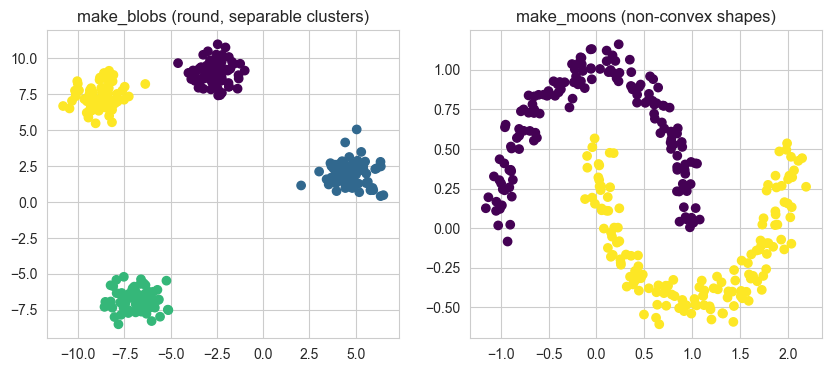

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [4]:
iris = sns.load_dataset('iris')
X_iris = iris.drop(columns=['species'])
y_iris_true = iris['species']

X_blobs, y_blobs_true = make_blobs(n_samples=300, centers=4, cluster_std=0.8, random_state=42)
X_moons, y_moons_true = make_moons(n_samples=300, noise=0.07, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(10,4))
axes[0].scatter(X_blobs[:,0], X_blobs[:,1], c=y_blobs_true, cmap='viridis')
axes[0].set_title('make_blobs (round, separable clusters)')
axes[1].scatter(X_moons[:,0], X_moons[:,1], c=y_moons_true, cmap='viridis')
axes[1].set_title('make_moons (non-convex shapes)')
plt.show()
iris

## 3. Preprocessing: Scaling
**Why scaling matters MORE here:** clustering and PCA rely directly on distances between points.
If one feature has a much larger scale (e.g. `fare` in dollars vs `age` in years), it will dominate
distance calculations and distort the clusters/components entirely.

In [4]:
scaler = StandardScaler()
X_iris_scaled = scaler.fit_transform(X_iris)
X_blobs_scaled = StandardScaler().fit_transform(X_blobs)
X_moons_scaled = StandardScaler().fit_transform(X_moons)
print("Scaled iris sample:\n", X_iris_scaled[:3])

Scaled iris sample:
 [[-0.90068117  1.01900435 -1.34022653 -1.3154443 ]
 [-1.14301691 -0.13197948 -1.34022653 -1.3154443 ]
 [-1.38535265  0.32841405 -1.39706395 -1.3154443 ]]


## 4. Clustering Algorithms

### 4.1 K-Means
**Idea:** partitions data into K clusters by repeatedly assigning points to the nearest centroid and
recomputing centroids until stable. Fast and simple, but assumes round/convex clusters of similar size
and requires choosing K upfront.


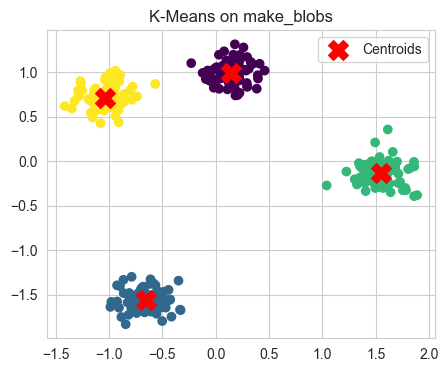

In [5]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_blobs = kmeans.fit_predict(X_blobs_scaled)

plt.figure(figsize=(5,4))
plt.scatter(X_blobs_scaled[:,0], X_blobs_scaled[:,1], c=labels_blobs, cmap='viridis')
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], c='red', marker='X', s=200, label='Centroids')
plt.title('K-Means on make_blobs')
plt.legend()
plt.show()

**Choosing K — Elbow Method:** plot inertia (within-cluster sum of squares) vs K. The "elbow"
point where the curve bends is a good choice — adding more clusters beyond that gives diminishing returns.

**Choosing K — Silhouette Score:** measures how similar a point is to its own cluster vs other
clusters (range -1 to 1, higher is better). Complements the elbow method.

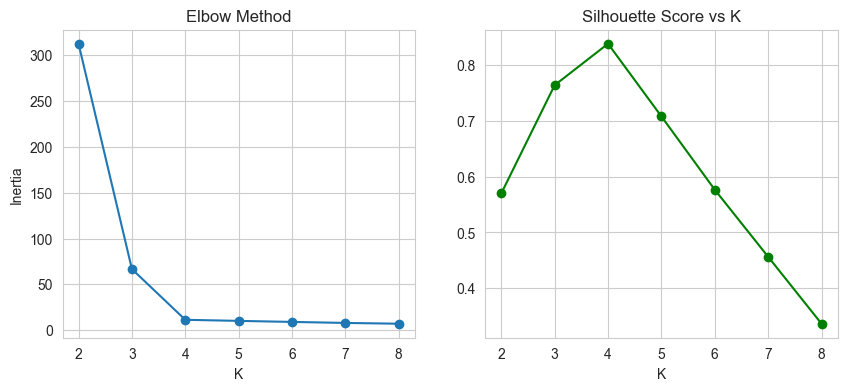

In [6]:
inertias, sil_scores = [], []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_blobs_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_blobs_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(10,4))
axes[0].plot(K_range, inertias, 'o-'); axes[0].set_title('Elbow Method'); axes[0].set_xlabel('K'); axes[0].set_ylabel('Inertia')
axes[1].plot(K_range, sil_scores, 'o-', color='green'); axes[1].set_title('Silhouette Score vs K'); axes[1].set_xlabel('K')
plt.show()

### 4.2 Hierarchical (Agglomerative) Clustering
**Idea:** starts with every point as its own cluster, then repeatedly merges the two closest clusters
until one cluster remains. No need to pick K upfront — you "cut" the resulting dendrogram tree at the
desired number of clusters. Slower than KMeans on large data (O(n²) or worse).

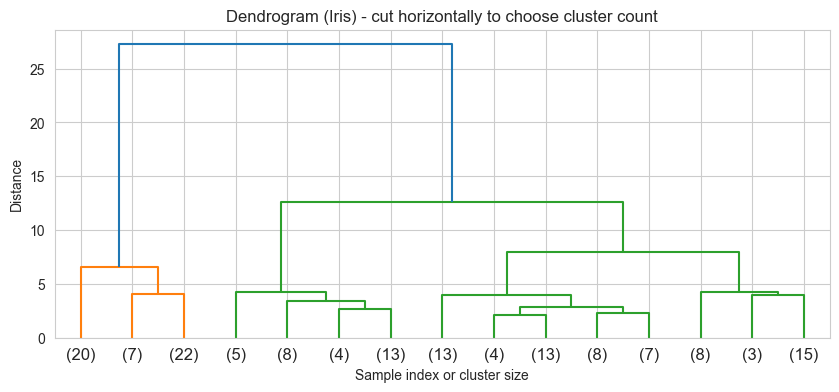

In [7]:
# Dendrogram - visualizes the merge order/distances. Cutting horizontally at a height gives clusters.
linked = linkage(X_iris_scaled, method='ward')
plt.figure(figsize=(10,4))
dendrogram(linked, truncate_mode='lastp', p=15)
plt.title('Dendrogram (Iris) - cut horizontally to choose cluster count')
plt.xlabel('Sample index or cluster size'); plt.ylabel('Distance')
plt.show()

In [8]:
agg = AgglomerativeClustering(n_clusters=3, linkage='ward')
labels_agg = agg.fit_predict(X_iris_scaled)
print("Silhouette score (Agglomerative on iris):", silhouette_score(X_iris_scaled, labels_agg))

Silhouette score (Agglomerative on iris): 0.446689041028591


### 4.3 DBSCAN (Density-Based Spatial Clustering)
**Idea:** groups points that are densely packed together, marking sparse points as noise/outliers.
Unlike KMeans, it can find NON-CONVEX shaped clusters (like the moons) and doesn't need K specified —
just `eps` (neighborhood radius) and `min_samples` (density threshold).

**Tuning eps/min_samples:** too small `eps` -> everything becomes noise; too large -> everything merges
into one cluster. Use a k-distance plot or trial and error, starting with min_samples = 2*dimensions.

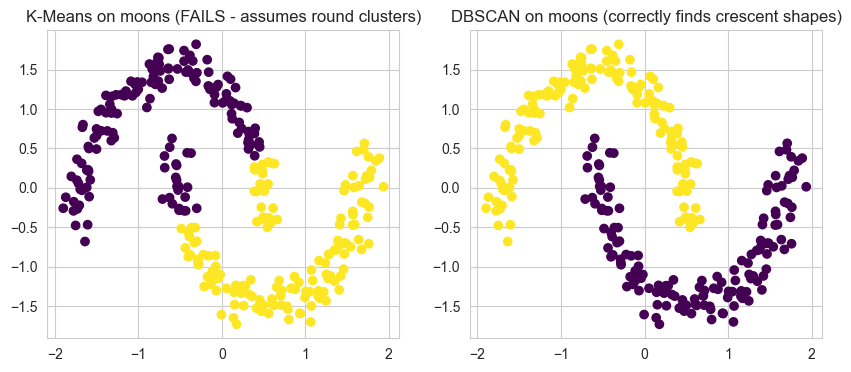

In [9]:
dbscan = DBSCAN(eps=0.3, min_samples=5)
labels_moons_dbscan = dbscan.fit_predict(X_moons_scaled)

# Compare KMeans vs DBSCAN on the moons dataset - this shows WHY DBSCAN exists
kmeans_moons = KMeans(n_clusters=2, random_state=42, n_init=10).fit_predict(X_moons_scaled)

fig, axes = plt.subplots(1, 2, figsize=(10,4))
axes[0].scatter(X_moons_scaled[:,0], X_moons_scaled[:,1], c=kmeans_moons, cmap='viridis')
axes[0].set_title('K-Means on moons (FAILS - assumes round clusters)')
axes[1].scatter(X_moons_scaled[:,0], X_moons_scaled[:,1], c=labels_moons_dbscan, cmap='viridis')
axes[1].set_title('DBSCAN on moons (correctly finds crescent shapes)')
plt.show()

### 4.4 Gaussian Mixture Models (GMM)
**Idea:** assumes data is generated from a mixture of several Gaussian (normal) distributions.
Unlike KMeans (hard assignment), GMM gives SOFT probabilistic cluster membership — each point gets a
probability of belonging to each cluster. Handles elliptical clusters better than KMeans.

In [ ]:
CLUSTER A         CLUSTER B
40 45 50          60 65 70

STUDENT 55



In [ ]:
MEDICAL DIAGNOSIS
PATIENT SYMPTONS

DIABETES  75%
THYROID  25 %%


ELCTRONICS 65
FASHION  


In [10]:
gmm = GaussianMixture(n_components=3, random_state=42)
labels_gmm = gmm.fit_predict(X_iris_scaled)
probs_gmm = gmm.predict_proba(X_iris_scaled)

print("Example soft cluster probabilities for first 5 points:\n", np.round(probs_gmm[:5], 2))
print("\nSilhouette score (GMM on iris):", silhouette_score(X_iris_scaled, labels_gmm))

Example soft cluster probabilities for first 5 points:
 [[0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]]

Silhouette score (GMM on iris): 0.4751434694267145


## 5. Clustering Evaluation Metrics
**Why:** since there's no ground-truth label in real unsupervised problems, we need metrics that
judge cluster quality from the data structure itself:
- **Silhouette Score** (-1 to 1): higher = well separated, dense clusters.
- **Davies-Bouldin Index** (0 to ∞): LOWER is better — measures average similarity between each
  cluster and its most similar one.
- **Calinski-Harabasz Index**: HIGHER is better — ratio of between-cluster to within-cluster dispersion.


In [11]:
algos = {
    'KMeans': KMeans(n_clusters=3, random_state=42, n_init=10).fit_predict(X_iris_scaled),
    'Agglomerative': AgglomerativeClustering(n_clusters=3).fit_predict(X_iris_scaled),
    'GMM': GaussianMixture(n_components=3, random_state=42).fit_predict(X_iris_scaled),
    'DBSCAN': DBSCAN(eps=0.6, min_samples=5).fit_predict(X_iris_scaled),
}

eval_rows = []
for name, labels in algos.items():
    n_clusters_found = len(set(labels)) - (1 if -1 in labels else 0)
    if n_clusters_found < 2:
        eval_rows.append({'Algorithm': name, 'Silhouette': np.nan, 'Davies-Bouldin': np.nan, 'Calinski-Harabasz': np.nan})
        continue
    eval_rows.append({
        'Algorithm': name,
        'Silhouette': silhouette_score(X_iris_scaled, labels),
        'Davies-Bouldin': davies_bouldin_score(X_iris_scaled, labels),
        'Calinski-Harabasz': calinski_harabasz_score(X_iris_scaled, labels)
    })

clustering_results = pd.DataFrame(eval_rows)
clustering_results

,Algorithm,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,KMeans,0.459948,0.833595,241.904402
1,Agglomerative,0.446689,0.803467,222.719164
2,GMM,0.475143,0.886715,141.231476
3,DBSCAN,0.402762,7.046802,91.023213


## 6. Dimensionality Reduction

### 6.1 PCA (Principal Component Analysis)
**Idea:** finds new axes (principal components) that capture the maximum variance in the data, ordered
by importance. Great for visualization, noise reduction, and speeding up downstream models. It's a
LINEAR technique — it may miss complex non-linear structure.

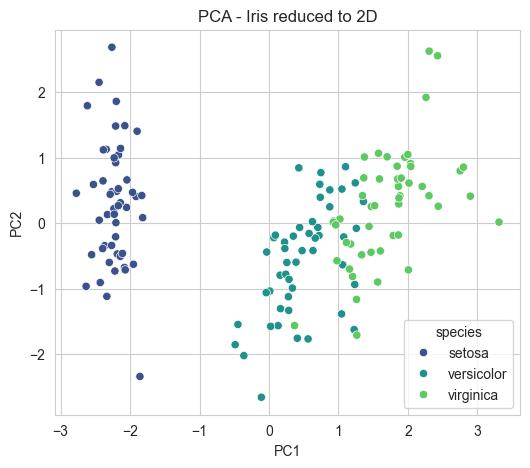

Explained variance ratio per component: [0.72962445 0.22850762]
Total variance captured by 2 components: 0.9581320720000165


In [12]:
pca = PCA(n_components=2)
X_iris_pca = pca.fit_transform(X_iris_scaled)

plt.figure(figsize=(6,5))
sns.scatterplot(x=X_iris_pca[:,0], y=X_iris_pca[:,1], hue=y_iris_true, palette='viridis')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.title('PCA - Iris reduced to 2D')
plt.show()

print("Explained variance ratio per component:", pca.explained_variance_ratio_)
print("Total variance captured by 2 components:", pca.explained_variance_ratio_.sum())

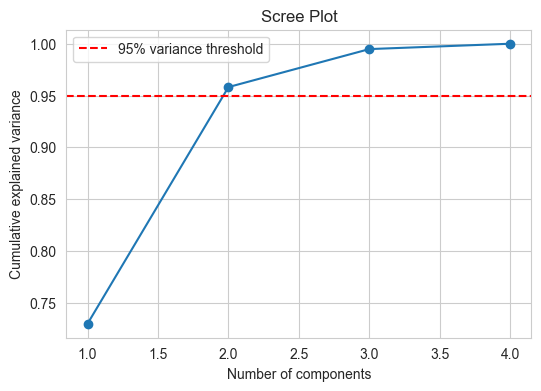

In [13]:
# Scree plot - helps decide how many components to keep (look for the "elbow")
pca_full = PCA().fit(X_iris_scaled)
plt.figure(figsize=(6,4))
plt.plot(range(1, len(pca_full.explained_variance_ratio_)+1), np.cumsum(pca_full.explained_variance_ratio_), 'o-')
plt.xlabel('Number of components'); plt.ylabel('Cumulative explained variance')
plt.title('Scree Plot')
plt.axhline(0.95, color='red', linestyle='--', label='95% variance threshold')
plt.legend()
plt.show()

### 6.2 t-SNE
**Idea:** a NON-LINEAR technique that preserves local neighborhood structure — great for visualizing
clusters that PCA can't separate linearly. Downsides: slow on large data, results vary by run
(stochastic), and distances between well-separated clusters aren't meaningful (only local structure is).

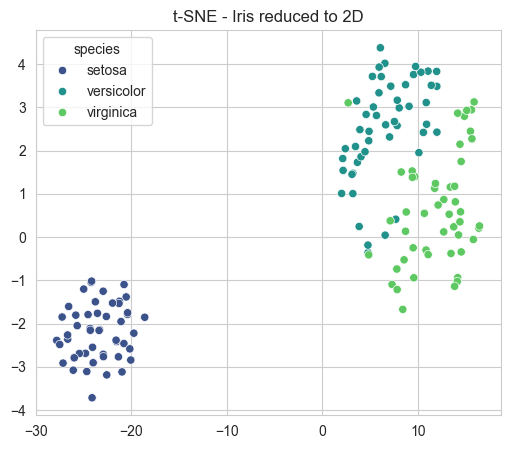

In [14]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_iris_tsne = tsne.fit_transform(X_iris_scaled)

plt.figure(figsize=(6,5))
sns.scatterplot(x=X_iris_tsne[:,0], y=X_iris_tsne[:,1], hue=y_iris_true, palette='viridis')
plt.title('t-SNE - Iris reduced to 2D')
plt.show()

### 6.3 UMAP
**Idea:** similar goal to t-SNE (non-linear, preserves local structure) but faster and better at
preserving GLOBAL structure too (relative distances between clusters are more meaningful than in t-SNE).
Increasingly preferred over t-SNE for large datasets.

In [15]:
if UMAP_AVAILABLE:
    reducer = umap.UMAP(n_components=2, random_state=42)
    X_iris_umap = reducer.fit_transform(X_iris_scaled)

    plt.figure(figsize=(6,5))
    sns.scatterplot(x=X_iris_umap[:,0], y=X_iris_umap[:,1], hue=y_iris_true, palette='viridis')
    plt.title('UMAP - Iris reduced to 2D')
    plt.show()
else:
    print("Skipping - install umap-learn to run this cell")

Skipping - install umap-learn to run this cell


### 6.4 PCA vs t-SNE vs UMAP — Side by Side
**Why compare:** PCA is fast & linear (good baseline, preserves global structure).
t-SNE/UMAP are non-linear and often separate clusters more clearly, at the cost of speed and
(for t-SNE) meaningful global distances.

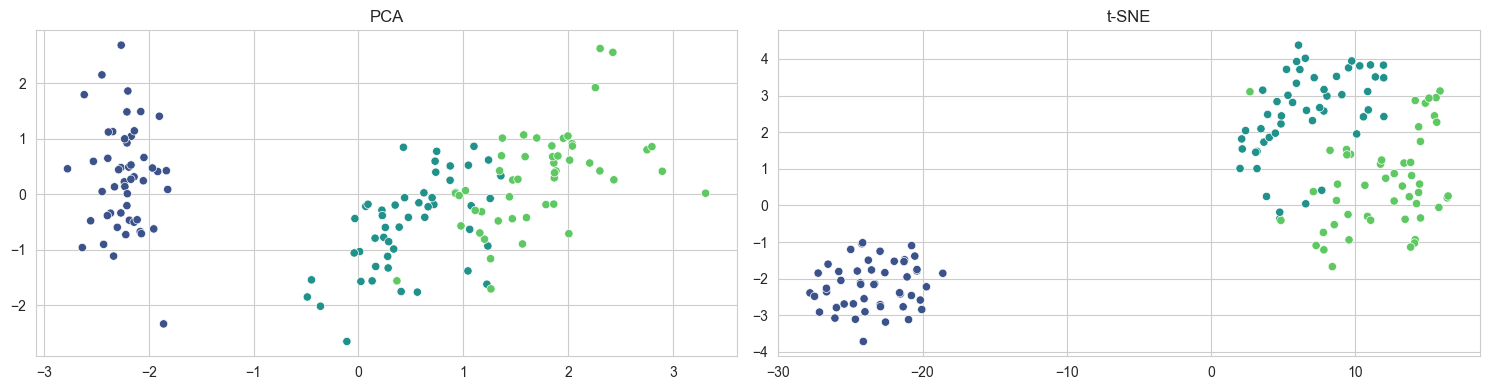

In [16]:
fig, axes = plt.subplots(1, 3 if UMAP_AVAILABLE else 2, figsize=(15,4))
sns.scatterplot(x=X_iris_pca[:,0], y=X_iris_pca[:,1], hue=y_iris_true, palette='viridis', ax=axes[0], legend=False)
axes[0].set_title('PCA')
sns.scatterplot(x=X_iris_tsne[:,0], y=X_iris_tsne[:,1], hue=y_iris_true, palette='viridis', ax=axes[1], legend=False)
axes[1].set_title('t-SNE')
if UMAP_AVAILABLE:
    sns.scatterplot(x=X_iris_umap[:,0], y=X_iris_umap[:,1], hue=y_iris_true, palette='viridis', ax=axes[2], legend=False)
    axes[2].set_title('UMAP')
plt.tight_layout()
plt.show()

## 7. Anomaly / Outlier Detection

### 7.1 Isolation Forest
**Idea:** randomly splits data repeatedly; anomalies are "easier to isolate" (need fewer splits)
because they're few and different. Very efficient, works well in high dimensions.

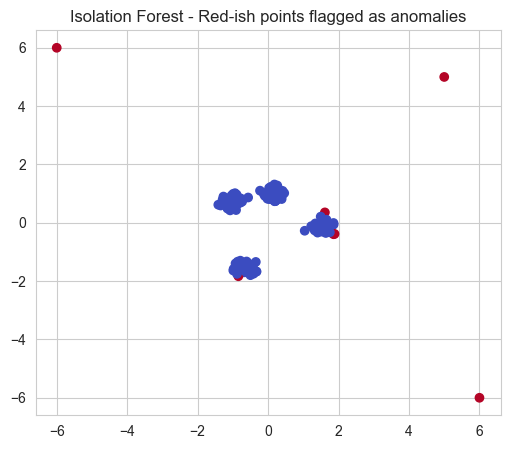

In [17]:
# Inject a few synthetic outliers into the blobs data for demonstration
X_with_outliers = np.vstack([X_blobs_scaled, np.array([[5,5],[6,-6],[-6,6]])])

iso = IsolationForest(contamination=0.02, random_state=42)
outlier_pred = iso.fit_predict(X_with_outliers)  # -1 = outlier, 1 = normal

plt.figure(figsize=(6,5))
plt.scatter(X_with_outliers[:,0], X_with_outliers[:,1], c=(outlier_pred == -1), cmap='coolwarm')
plt.title('Isolation Forest - Red-ish points flagged as anomalies')
plt.show()

### 7.2 One-Class SVM
**Idea:** learns a boundary that encloses "normal" data as tightly as possible; anything outside the
boundary is flagged as an anomaly. Effective for high-dimensional data but sensitive to parameter choice.

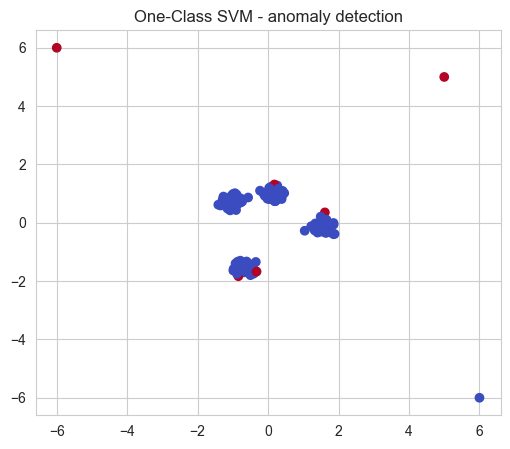

In [18]:
ocsvm = OneClassSVM(nu=0.02, kernel='rbf', gamma='scale')
outlier_pred_svm = ocsvm.fit_predict(X_with_outliers)

plt.figure(figsize=(6,5))
plt.scatter(X_with_outliers[:,0], X_with_outliers[:,1], c=(outlier_pred_svm == -1), cmap='coolwarm')
plt.title('One-Class SVM - anomaly detection')
plt.show()

### 7.3 Local Outlier Factor (LOF)
**Idea:** compares the local density of a point to the local density of its neighbors. A point in a
much sparser neighborhood than its neighbors is flagged as an outlier. Good for detecting LOCAL
anomalies (that aren't extreme globally, but stand out relative to nearby points).

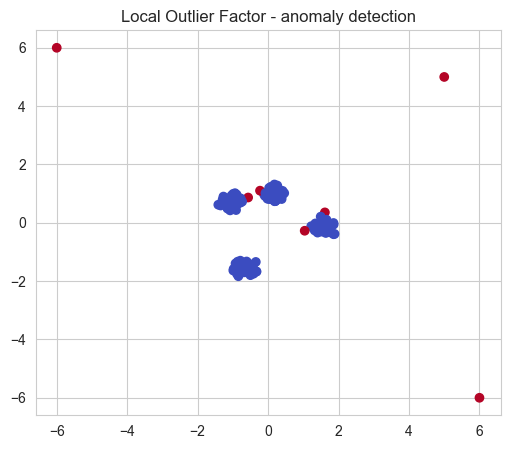

In [19]:
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.02)
outlier_pred_lof = lof.fit_predict(X_with_outliers)

plt.figure(figsize=(6,5))
plt.scatter(X_with_outliers[:,0], X_with_outliers[:,1], c=(outlier_pred_lof == -1), cmap='coolwarm')
plt.title('Local Outlier Factor - anomaly detection')
plt.show()

## 8. Association Rule Learning (Apriori)
**Idea:** finds "if X then Y" rules in transactional data (classic use case: market-basket analysis —
"customers who buy bread also buy butter"). Key metrics:
- **Support:** how frequently the itemset appears in all transactions.
- **Confidence:** P(Y | X) — how often Y is bought when X is bought.
- **Lift:** how much more likely Y is bought when X is bought, compared to Y's baseline rate.
  Lift > 1 means a genuinely useful association (not just coincidence).


In [20]:
if MLXTEND_AVAILABLE:
    # Synthetic market-basket transactions
    transactions = [
        ['milk', 'bread', 'butter'],
        ['bread', 'butter'],
        ['milk', 'bread'],
        ['milk', 'bread', 'butter', 'eggs'],
        ['bread', 'eggs'],
        ['milk', 'eggs'],
        ['milk', 'bread', 'eggs'],
        ['butter', 'eggs'],
    ]

    te = TransactionEncoder()
    te_array = te.fit(transactions).transform(transactions)
    basket_df = pd.DataFrame(te_array, columns=te.columns_)

    frequent_itemsets = apriori(basket_df, min_support=0.3, use_colnames=True)
    rules = association_rules(frequent_itemsets, metric='lift', min_threshold=1.0)
    print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].sort_values('lift', ascending=False))
else:
    print("Skipping - install mlxtend to run this cell")

Skipping - install mlxtend to run this cell


## 9. Practical Combo: PCA + KMeans
**Why combine them:** clustering on high-dimensional data can suffer from the "curse of
dimensionality" (distances become less meaningful). Reducing dimensions with PCA first, then
clustering, often gives cleaner, faster results.

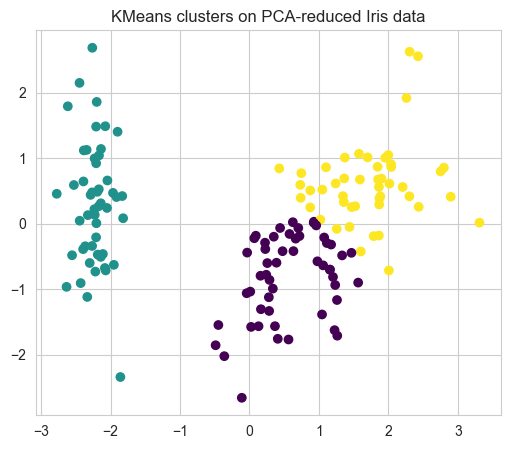

Silhouette score (PCA + KMeans): 0.5091683341538228


In [21]:
X_pca_for_cluster = PCA(n_components=2).fit_transform(X_iris_scaled)
kmeans_after_pca = KMeans(n_clusters=3, random_state=42, n_init=10).fit_predict(X_pca_for_cluster)

plt.figure(figsize=(6,5))
plt.scatter(X_pca_for_cluster[:,0], X_pca_for_cluster[:,1], c=kmeans_after_pca, cmap='viridis')
plt.title('KMeans clusters on PCA-reduced Iris data')
plt.show()

print("Silhouette score (PCA + KMeans):", silhouette_score(X_pca_for_cluster, kmeans_after_pca))

## 10. Final Clustering Comparison Table

In [22]:
clustering_results

,Algorithm,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,KMeans,0.459948,0.833595,241.904402
1,Agglomerative,0.446689,0.803467,222.719164
2,GMM,0.475143,0.886715,141.231476
3,DBSCAN,0.402762,7.046802,91.023213


## 11. Summary — Topics Covered in This Notebook
- Clustering: K-Means (+ Elbow Method + Silhouette), Hierarchical/Agglomerative (+ dendrogram),
  DBSCAN (+ eps/min_samples tuning), Gaussian Mixture Models (soft clustering)
- Clustering evaluation: Silhouette Score, Davies-Bouldin Index, Calinski-Harabasz Index
- Dimensionality reduction: PCA (+ scree plot), t-SNE, UMAP, and a side-by-side comparison
- Anomaly/outlier detection: Isolation Forest, One-Class SVM, Local Outlier Factor
- Association rule learning: Apriori algorithm, support/confidence/lift
- Practical combo: PCA + KMeans

## 🎓 You now have all 3 notebooks:
1. `01_Supervised_Regression.ipynb`
2. `02_Supervised_Classification.ipynb`
3. `03_Unsupervised_Learning.ipynb`

Together these cover essentially the full standard supervised + unsupervised ML curriculum for
tabular data. Revisit these instead of re-watching tutorials!
